In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

##PART A

In [4]:
#load dataset
fear_df = pd.read_csv("/content/fear_greed_index.csv")
historical_df = pd.read_csv("/content/historical_data.csv")

/tmp/ipykernel_1442/3356500205.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  historical_df = pd.read_csv("/content/historical_data.csv")


In [5]:
print("Fear & Greed Dataset Shape:")
print(fear_df.shape)

fear_df.head()

Fear & Greed Dataset Shape:
(2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
print("Historical Dataset Shape:")
print(historical_df.shape)

historical_df.head()

Historical Dataset Shape:
(125831, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [58]:
#Missing Values
print("Fear & Greed Missing Values")
print(fear_df.isnull().sum())

Fear & Greed Missing Values
timestamp         0
value             0
classification    0
date              0
date_only         0
dtype: int64


In [8]:
print("Historical Dataset Missing Values")
print(historical_df.isnull().sum())

Historical Dataset Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                1
Timestamp IST       1
Start Position      1
Direction           1
Closed PnL          1
Transaction Hash    1
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64


In [9]:
#Duplicates Values
print("Duplicates in Fear & Greed  Data:",
      fear_df.duplicated().sum())

print("Duplicates in Historical Data:",
      historical_df.duplicated().sum())

Duplicates in Fear & Greed  Data: 0
Duplicates in Historical Data: 0


In [10]:
#Convert timestamps
fear_df['date'] = pd.to_datetime(fear_df['date'])

fear_df['date_only'] = fear_df['date'].dt.date

In [11]:
historical_df['Timestamp IST'] = pd.to_datetime(
    historical_df['Timestamp IST'],
    dayfirst=True
)

historical_df['date_only'] = historical_df['Timestamp IST'].dt.date

In [12]:
historical_df['date_only'].head(10)

,date_only
0,2024-12-02
1,2024-12-02
2,2024-12-02
3,2024-12-02
4,2024-12-02
5,2024-12-02
6,2024-12-02
7,2024-12-02
8,2024-12-02
9,2024-12-02


In [13]:
#merging both dataset fear and historical
merged_df = pd.merge(
    historical_df,
    fear_df[['date_only','classification']],
    on='date_only',
    how='left'
)

In [66]:
merged_df['sentiment_group'] = merged_df['classification'].replace({
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed',
    'Neutral': 'Neutral'
})

In [67]:
merged_df['sentiment_group'].value_counts()

,count
sentiment_group,
Greed,56643
Fear,44603
Neutral,24578


In [14]:
merged_df.shape

(125831, 18)

In [15]:
merged_df[['date_only','classification']].head()

,date_only,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [16]:
print("Merged Missing Values")
print(merged_df.isnull().sum())

Merged Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                1
Timestamp IST       1
Start Position      1
Direction           1
Closed PnL          1
Transaction Hash    1
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
date_only           1
classification      7
dtype: int64


In [17]:
#daily PnL per trader (or per account)
daily_pnl = merged_df.groupby(
    ['Account','date_only']
)['Closed PnL'].sum().reset_index()

print(daily_pnl.shape)
daily_pnl.head()

(1544, 3)


,Account,date_only,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [18]:
#Win Rate
merged_df['win_trade'] = np.where(
    merged_df['Closed PnL'] > 0,
    1,
    0
)

In [19]:
win_rate = merged_df.groupby(
    'Account'
)['win_trade'].mean().reset_index()

win_rate['win_rate_percent'] = (
    win_rate['win_trade'] * 100
)

win_rate.head()

,Account,win_trade,win_rate_percent
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,44.271978
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.455215,45.521472
3,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0.234987,23.498695
4,0x430f09841d65beb3f27765503d0f850b8bce7713,0.484236,48.423605


In [20]:
#Average Trade Size
avg_trade_size = merged_df.groupby(
    'Account'
)['Size USD'].mean().reset_index()

avg_trade_size.rename(
    columns={'Size USD':'avg_trade_size'},
    inplace=True
)

avg_trade_size.head()

,Account,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1729.941104
3,0x420ab45e0bd8863569a5efbb9c05d91f40624641,5189.367128
4,0x430f09841d65beb3f27765503d0f850b8bce7713,2397.824753


In [21]:
merged_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date_only', 'classification', 'win_trade'],
      dtype='object')

In [22]:
#Leverage Distribution
merged_df['Size USD'].describe()

,Size USD
count,1.258310e+05
mean,6.741709e+03
std,4.468967e+04
min,0.000000e+00
25%,1.999400e+02
50%,6.149700e+02
75%,2.222195e+03
max,3.921431e+06


In [23]:
#No of trades per day
trades_per_day = merged_df.groupby(
    'date_only'
).size().reset_index(
    name='trade_count'
)

trades_per_day.head()

,date_only,trade_count
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [24]:
#long short ratio
merged_df['Side'].value_counts()

,count
Side,
BUY,63478
SELL,62352


In [25]:
merged_df['trade_direction'] = merged_df['Side'].apply(
    lambda x: 'Long' if 'BUY' in str(x).upper()
    else 'Short'
)

In [26]:
long_short_ratio = merged_df[
    'trade_direction'
].value_counts(normalize=True) * 100

print(long_short_ratio)

trade_direction
Long     50.447028
Short    49.552972
Name: proportion, dtype: float64


In [27]:
pd.crosstab(
    merged_df['classification'],
    merged_df['trade_direction'],
    normalize='index'
) * 100

trade_direction,Long,Short
classification,,
Extreme Fear,56.146614,43.853386
Extreme Greed,45.312500,54.687500
Fear,49.745856,50.254144
Greed,51.205214,48.794786
Neutral,52.929449,47.070551


##PART B

In [68]:
#Part b
#Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
#PnL
pnl_by_sentiment = merged_df.groupby(
    'sentiment_group'
)['Closed PnL'].mean().reset_index()

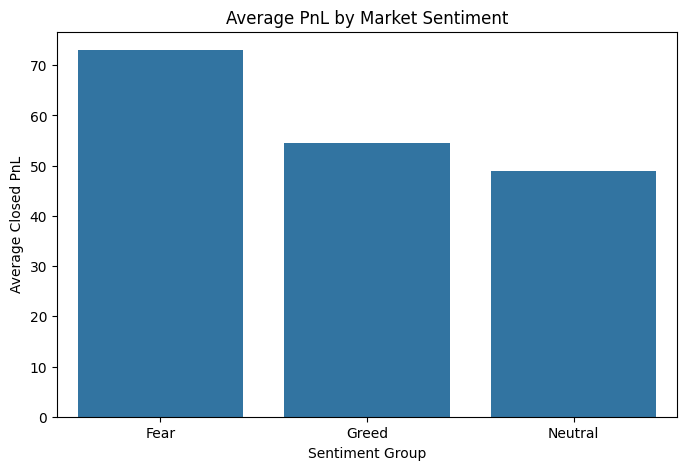

In [70]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=pnl_by_sentiment,
    x='sentiment_group',
    y='Closed PnL'
)

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Sentiment Group")
plt.ylabel("Average Closed PnL")

plt.show()

In [31]:
#win rate
merged_df['win_trade'] = np.where(
    merged_df['Closed PnL'] > 0,
    1,
    0
)

In [71]:
win_rate = merged_df.groupby(
    'sentiment_group'
)['win_trade'].mean().reset_index()

win_rate['win_rate_percent'] = win_rate['win_trade'] * 100

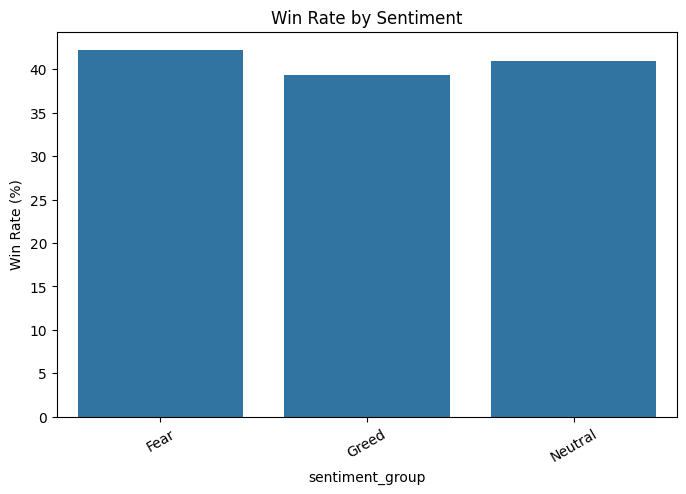

In [73]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=win_rate,
    x='sentiment_group',
    y='win_rate_percent'
)

plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=30)

plt.show()

In [74]:
#drawdown_proxy
daily_pnl = merged_df.groupby(
    ['Account', 'date_only', 'sentiment_group']
)['Closed PnL'].sum().reset_index()

drawdown_proxy = daily_pnl.groupby(
    'sentiment_group'
)['Closed PnL'].min().reset_index()

drawdown_proxy

,sentiment_group,Closed PnL
0,Fear,-108604.496278
1,Greed,-358963.139984
2,Neutral,-36229.641811


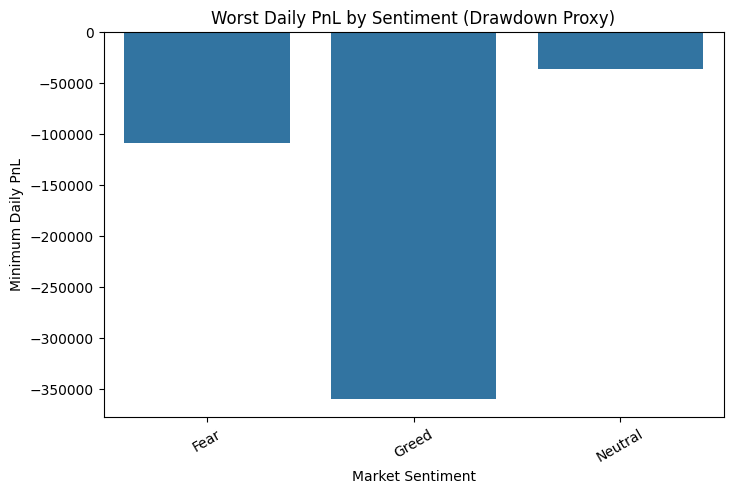

In [77]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=drawdown_proxy,
    x='sentiment_group',
    y='Closed PnL'
)

plt.title("Worst Daily PnL by Sentiment (Drawdown Proxy)")
plt.xlabel("Market Sentiment")
plt.ylabel("Minimum Daily PnL")

plt.xticks(rotation=30)

plt.show()

In [81]:
#Do Traders Change Behavior?
#trade frequency
daily_trades = merged_df.groupby(
    ['date_only','classification']
).size().reset_index(name='trade_count')

daily_trades.head()

,date_only,classification,trade_count
0,2023-05-01,Greed,3
1,2023-12-05,Extreme Greed,9
2,2023-12-14,Greed,11
3,2023-12-15,Greed,2
4,2023-12-16,Greed,3


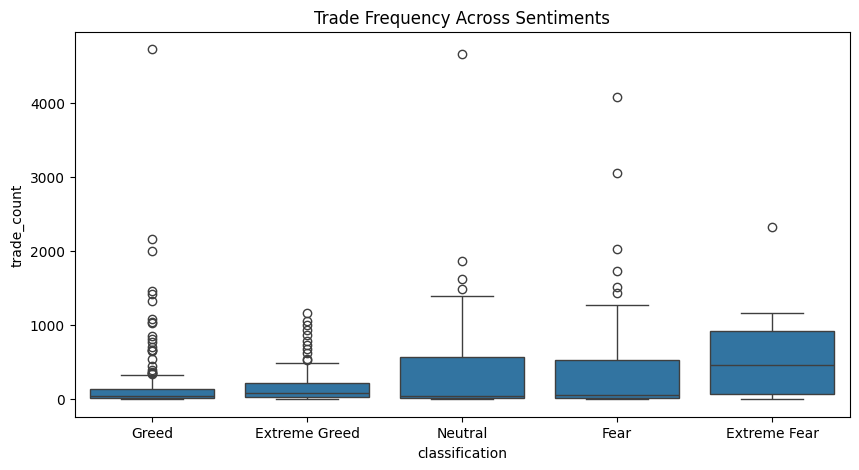

In [35]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=daily_trades,
    x='classification',
    y='trade_count'
)

plt.title("Trade Frequency Across Sentiments")

plt.show()

In [62]:
#leverage
size_analysis = merged_df.groupby(
    'classification'
)['Size USD'].mean().reset_index()

size_analysis

,classification,Size USD
0,Extreme Fear,4864.464791
1,Extreme Greed,4214.495658
2,Fear,9367.339134
3,Greed,6814.133782
4,Neutral,5622.226620


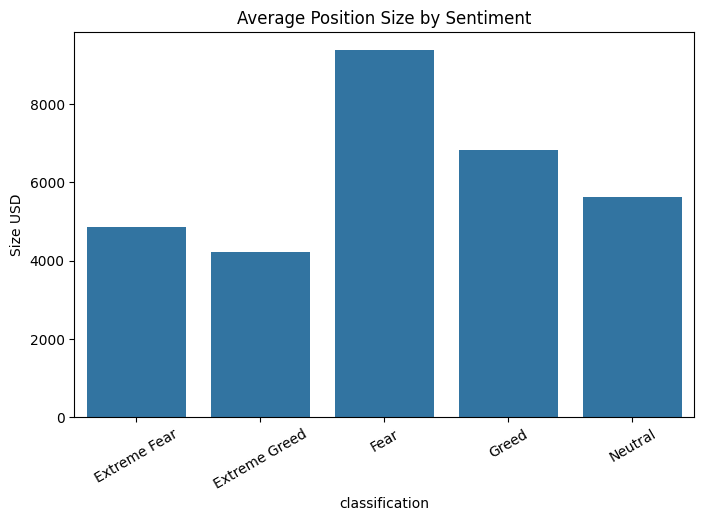

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=size_analysis,
    x='classification',
    y='Size USD'
)

plt.title("Average Position Size by Sentiment")

plt.xticks(rotation=30)

plt.show()

In [39]:
print(merged_df.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date_only', 'classification', 'win_trade', 'trade_direction']


In [40]:
#long/short bias
long_short = pd.crosstab(
    merged_df['classification'],
    merged_df['trade_direction']
)

long_short

trade_direction,Long,Short
classification,,
Extreme Fear,4718,3685
Extreme Greed,9744,11760
Fear,18008,18192
Greed,17993,17146
Neutral,13009,11569


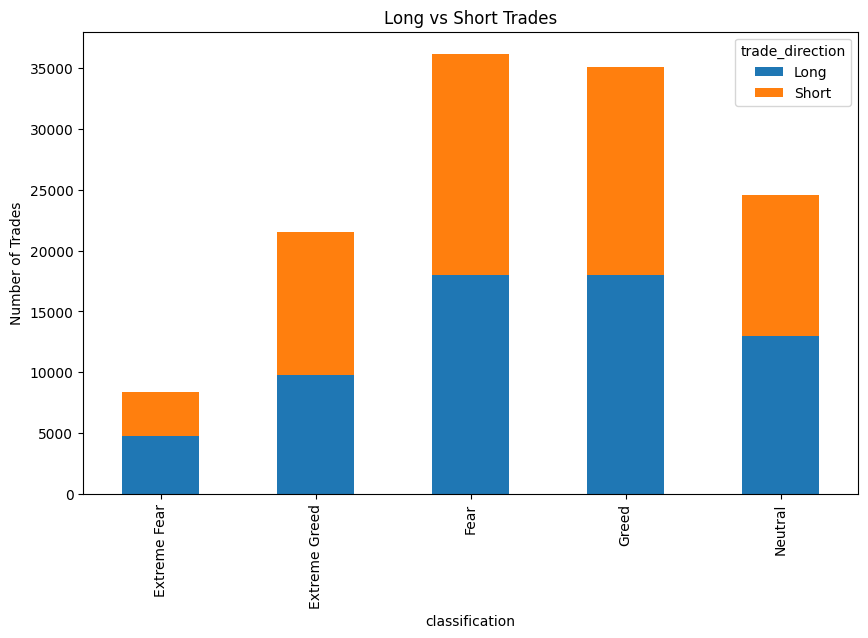

In [41]:
long_short.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Long vs Short Trades")
plt.ylabel("Number of Trades")

plt.show()

In [63]:
#position sizes
position_size = merged_df.groupby(
    'classification'
)['Size USD'].mean().reset_index()

position_size

,classification,Size USD
0,Extreme Fear,4864.464791
1,Extreme Greed,4214.495658
2,Fear,9367.339134
3,Greed,6814.133782
4,Neutral,5622.226620


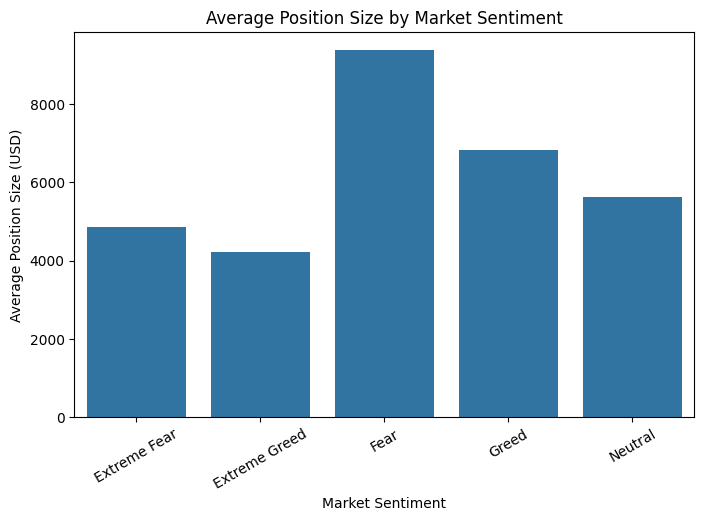

In [64]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=position_size,
    x='classification',
    y='Size USD'
)

plt.title("Average Position Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Position Size (USD)")

plt.xticks(rotation=30)

plt.show()

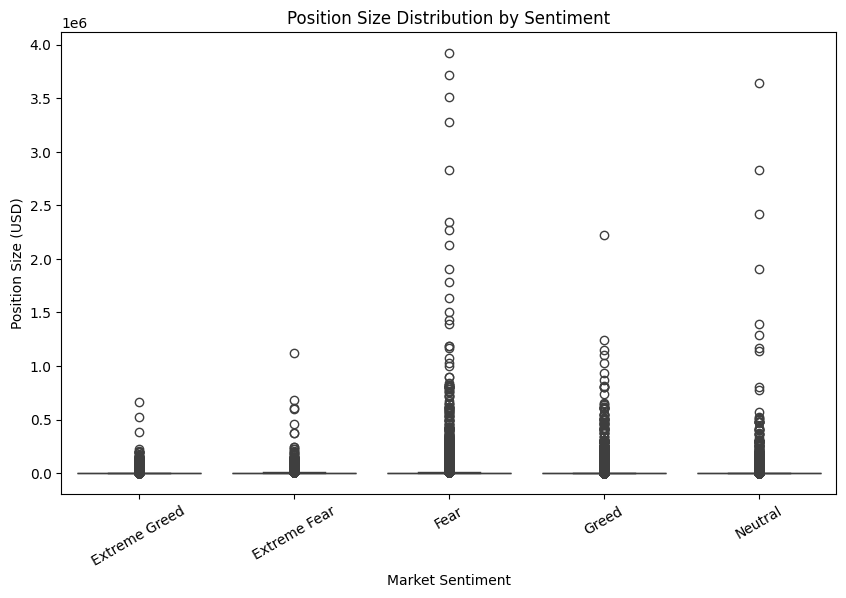

In [65]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged_df,
    x='classification',
    y='Size USD'
)

plt.title("Position Size Distribution by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Position Size (USD)")

plt.xticks(rotation=30)

plt.show()

In [46]:
#Identify 2–3 segments (examples):
#high leverage vs low leverage traders
avg_trade_size = merged_df.groupby(
    'Account'
)['Size USD'].mean()

In [47]:
threshold = avg_trade_size.median()

In [48]:
merged_df['size_segment'] = merged_df['Account'].map(
    lambda x:
    'High Size Trader'
    if avg_trade_size[x] >= threshold
    else 'Low Size Trader'
)

In [49]:
merged_df.groupby(
    'size_segment'
)['Closed PnL'].mean()

,Closed PnL
size_segment,
High Size Trader,90.146386
Low Size Trader,19.343792


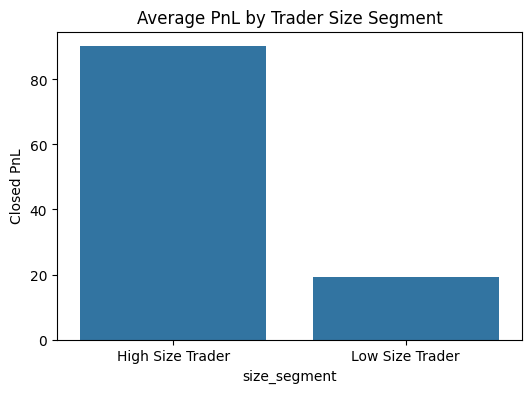

In [50]:
segment_pnl = merged_df.groupby(
    'size_segment'
)['Closed PnL'].mean().reset_index()

plt.figure(figsize=(6,4))

sns.barplot(
    data=segment_pnl,
    x='size_segment',
    y='Closed PnL'
)

plt.title("Average PnL by Trader Size Segment")
plt.show()

In [51]:
#Frequent vs Infrequent Traders
trade_count = merged_df.groupby(
    'Account'
).size()

median_trade = trade_count.median()

merged_df['frequency_segment'] = merged_df[
    'Account'
].map(
    lambda x:
    'Frequent'
    if trade_count[x] >= median_trade
    else 'Infrequent'
)

In [52]:
merged_df.groupby(
    'frequency_segment'
)['Closed PnL'].mean()

,Closed PnL
frequency_segment,
Frequent,41.517916
Infrequent,244.465499


In [54]:
#Consistent Winners v/s Inconsistent
win_rate_trader = merged_df.groupby(
    'Account'
)['win_trade'].mean()

In [55]:
winner_threshold = win_rate_trader.median()

merged_df['winner_segment'] = merged_df['Account'].map(
    lambda x:
    'Consistent Winner'
    if win_rate_trader[x] >= winner_threshold
    else 'Inconsistent Trader'
)

In [56]:
merged_df.groupby(
    'winner_segment'
)['Closed PnL'].mean()

,Closed PnL
winner_segment,
Consistent Winner,43.853757
Inconsistent Trader,78.732279


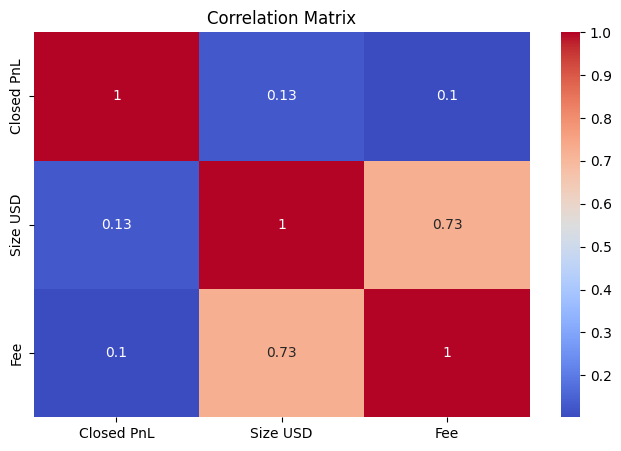

In [57]:
#Heatmap
numeric_cols = [
    'Closed PnL',
    'Size USD',
    'Fee'
]

corr = merged_df[numeric_cols].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

## Insight 1: Trading Performance Was Strongest During Fear Periods

The analysis shows that the highest average profit (PnL) was recorded during Fear periods. At the same time, average position sizes were also larger than in other sentiment. The combination of larger position sizes and higher profitability indicates that Fear periods created attractive trading opportunities despite negative market sentiment.

## Insight 2: Higher Profitability Was Not Driven by Higher Win Rates

Although Fear periods generated the highest average profitability, win rates remained relatively similar across Fear, Greed, and Neutral market conditions. This indicates that stronger performance was not the result of winning a greater percentage of trades. Instead, profitability appears to have been driven by larger gains from successful trades, suggesting that trade quality and position management played a more important role than win rate alone.

Win Rate:
42% vs 39%

PnL:
73 vs 55

## Insight 3: Position Sizing Appears More Important Than Trade Direction

The distribution of long and short trades remained relatively balanced across different sentiment conditions, with no strong directional bias observed. However, noticeable differences were seen in profitability and average position sizes. This suggests that trading performance was influenced more by position sizing and fear decisions than by whether a trade was long or short.

##PART C

##STRATEGY 1
Avoid overtrading. Infrequent traders generated significantly higher average PnL (244.47) compared to frequent traders (41.52), suggesting that focusing on fewer high-quality trades may be more effective than increasing trade frequency.

##STRATEGY 2
During Fear periods, increase position sizes selectively for high-conviction trades, as Fear days showed the highest average profitability in the dataset, with an average PnL of approximately 111.17 compared to 64.75 during Greed periods.